# Risk Decomposition via PCA

## Purpose

Notebook 04 tells us how the strategy performed. This notebook asks where the portfolio's risk comes from.

Portfolio variance is the quadratic form

$$w^\top\Sigma w,$$

where $w$ is the portfolio weight vector and $\Sigma$ is the stock-return covariance matrix. PCA gives an orthogonal basis for this covariance matrix, so we can split variance into common-factor directions and the remaining residual directions.

The goals are:
1. Estimate the sample covariance matrix $\Sigma=\frac{1}{T-1}X_c^\top X_c$.
2. Eigendecompose $\Sigma$ with PCA.
3. Use the Marchenko-Pastur cutoff to separate large signal-like eigenvalues from the noise bulk.
4. Compare sample covariance to Ledoit-Wolf shrinkage.
5. Decompose the current long-only portfolio variance into top-$k$ PCA risk and the orthogonal remainder.

### Terms used in this notebook

| Term | Meaning |
|------|---------|
| **Covariance matrix** $\Sigma$ | $N\times N$ matrix with $\Sigma_{ij}=\mathrm{Cov}(r_i,r_j)$ |
| **PCA** | Eigendecomposition of $\Sigma$ |
| **Eigenvector** | A portfolio-like direction in stock space |
| **Eigenvalue** | Variance explained along that eigenvector |
| **Scree plot** | Eigenvalues plotted from largest to smallest |
| **Marchenko-Pastur distribution** | Random-matrix benchmark for the eigenvalue noise bulk |
| **Shrinkage estimator** | A weighted average of noisy sample covariance and a structured target |
| **Systematic risk** | Variance in common PCA directions |
| **Idiosyncratic risk** | Variance outside the retained PCA directions |
| **Portfolio variance** | The quantity $w^\top\Sigma w$ being decomposed |

## Outputs

Eigenvalue spectrum, Marchenko-Pastur cutoff, Ledoit-Wolf comparison, and a portfolio variance decomposition table.

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Load Data](#load-data)
3. [Sample Covariance and PCA](#sample-covariance-and-pca)
4. [Marchenko-Pastur Noise Separation](#marchenkopastur-noise-separation)
5. [Ledoit-Wolf Shrinkage](#ledoitwolf-shrinkage)
6. [Portfolio Variance Decomposition](#portfolio-variance-decomposition)
7. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/05_risk_decomposition', exist_ok=True)

RANDOM_STATE = 3

In [2]:
"""
==================================
Load returns and backtest holdings
==================================
"""
df_returns = pd.read_csv('../data/processed/returns_monthly.csv', index_col=0, parse_dates=True)
df_backtest = pd.read_csv('../data/processed/backtest_returns.csv', index_col=0, parse_dates=True)

print(f"Returns:   {df_returns.shape}")
print(f"Backtest:  {df_backtest.shape}")

Returns:   (251, 501)
Backtest:  (239, 5)


## Sample Covariance and PCA

Let $X_c\in\mathbb{R}^{T\times N}$ be the centered return matrix. Each column has its time-series mean subtracted. The sample covariance matrix is

$$\Sigma=\frac{1}{T-1}X_c^\top X_c.$$

PCA eigendecomposes this matrix:

$$\Sigma=V\Lambda V^\top,$$

where

$$\Lambda=\mathrm{diag}(\lambda_1,\lambda_2,\ldots,\lambda_N), \quad \lambda_1\ge\lambda_2\ge\cdots.$$

The columns of $V$ are principal component directions in stock space. The eigenvalues are the variance along those directions.

`sklearn.decomposition.PCA` computes this through an SVD of $X_c$:

$$X_c=USV^\top,$$

which implies

$$\Sigma=\frac{1}{T-1}VS^2V^\top.$$

In [3]:
"""
==================================
PCA via sklearn
==================================
"""
# Use a balanced panel: keep stocks present for most of the sample, then use
# the months where all of them coexist. thresh must be high — a low thresh admits
# short-history stocks, and the chained dropna() then truncates EVERY stock to that
# short window (e.g. thresh=60 collapses the panel to 60 months, leaving N >> T and a
# rank-deficient covariance). Maximizing observations matters most here.
valid = df_returns.dropna(thresh=240, axis=1).dropna()
X = valid.values
X_centered = X - X.mean(axis=0)

n_obs, n_assets = X_centered.shape

# Sample covariance
cov = np.cov(X_centered, rowvar=False, ddof=1)

# sklearn PCA — fits on the centered data
pca = PCA()
pca.fit(X_centered)

# Build the same result dict so downstream cells are unchanged
pca_result = {
    'eigenvalues': pca.explained_variance_,
    'eigenvectors': pca.components_.T,   # sklearn returns (k x N); we want (N x k)
    'explained_ratio': pca.explained_variance_ratio_,
    'tickers': valid.columns.tolist(),
    'n_obs': n_obs,
    'n_assets': n_assets,
    'cov': cov,
}

print(f"Number of assets: {pca_result['n_assets']}")
print(f"Number of observations: {pca_result['n_obs']}")
print(f"\nTop 10 eigenvalues:")
for i, ev in enumerate(pca_result['eigenvalues'][:10]):
    print(f"  PC{i+1}: {ev:.6f}  ({pca_result['explained_ratio'][i]*100:.2f}%)")

Number of assets: 394
Number of observations: 240

Top 10 eigenvalues:
  PC1: 1.048239  (34.10%)
  PC2: 0.112295  (3.65%)
  PC3: 0.104251  (3.39%)
  PC4: 0.092663  (3.01%)
  PC5: 0.071925  (2.34%)
  PC6: 0.057767  (1.88%)
  PC7: 0.053078  (1.73%)
  PC8: 0.047010  (1.53%)
  PC9: 0.041681  (1.36%)
  PC10: 0.040488  (1.32%)


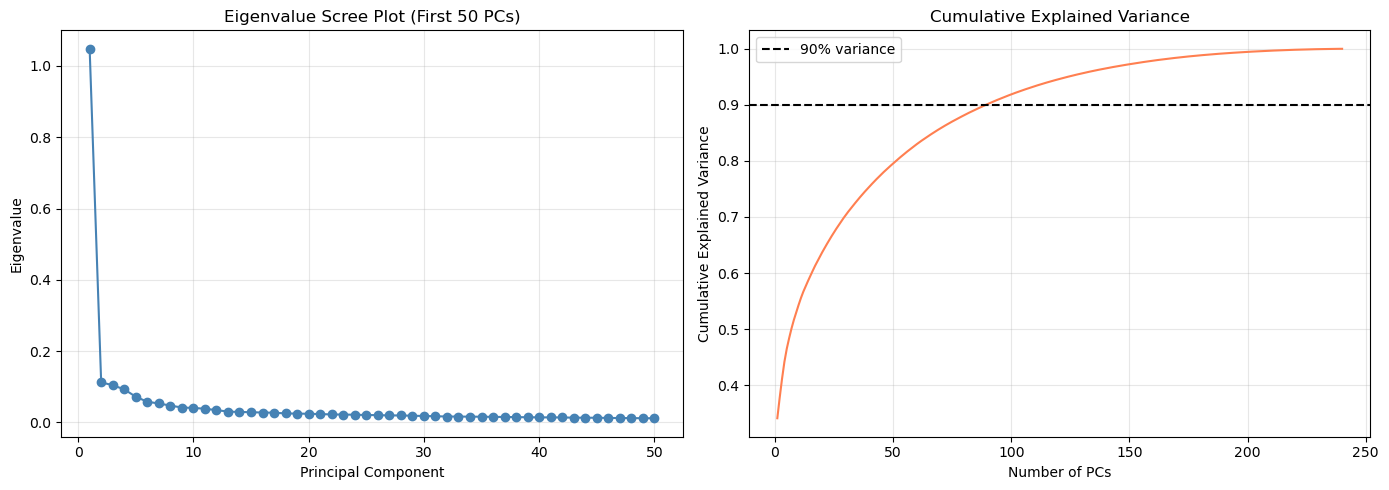

PCs needed for 90% variance: 90


In [4]:
"""
==================================
Eigenvalue scree plot
==================================
"""
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (first 50 PCs)
ax = axes[0]
n_show = 50
ax.plot(range(1, n_show+1), pca_result['eigenvalues'][:n_show], 'o-', color='steelblue')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue Scree Plot (First 50 PCs)')
ax.grid(alpha=0.3)

# Cumulative explained variance
ax = axes[1]
cum_var = np.cumsum(pca_result['explained_ratio'])
ax.plot(range(1, len(cum_var)+1), cum_var, color='coral')
ax.axhline(y=0.9, color='black', linestyle='--', label='90% variance')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/pca_scree.png', dpi=150, bbox_inches='tight')
plt.show()

# How many PCs for 90% variance?
n_90 = np.searchsorted(cum_var, 0.9) + 1
print(f"PCs needed for 90% variance: {n_90}")

## Marchenko-Pastur Noise Separation

Random matrix theory gives a useful benchmark for deciding how many principal components are larger than we would expect from noise.

For a random matrix with iid entries and variance $\sigma^2$, the eigenvalues of its sample covariance concentrate inside the Marchenko-Pastur interval:

$$\lambda_{\pm}=\sigma^2\left(1+\frac{1}{q}\pm2\sqrt{\frac{1}{q}}\right), \quad q=\frac{T}{N}.$$

Eigenvalues inside $[\lambda_-,\lambda_+]$ are consistent with a no-factor random matrix. Eigenvalues above $\lambda_+$ are candidates for real common factors.

This is not magic; it is a rule of thumb with assumptions. Returns are not iid normal draws. But it is better than choosing $k$ by eye from a scree plot.

q = T/N = 0.6091
sigma^2 (scale): 0.007802
MP bounds: [0.000617, 0.040603]
Number of signal eigenvalues (above MP upper bound): 9


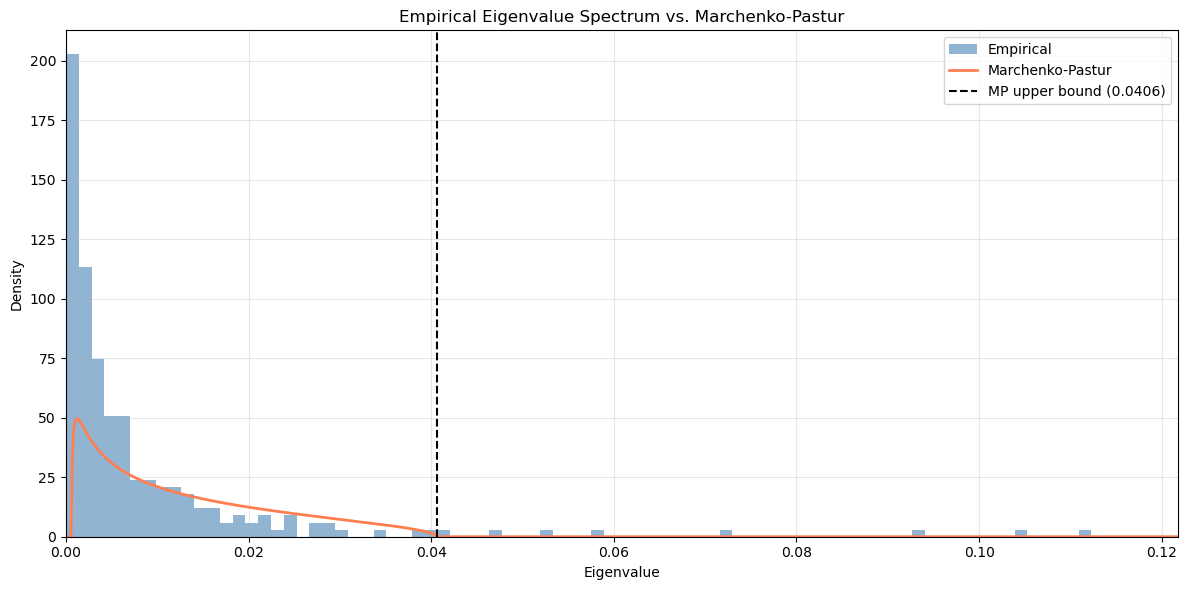

In [5]:
"""
==================================
Marchenko-Pastur cutoff
==================================
"""
def marchenko_pastur_bounds(q, sigma_sq=1.0):
    """Compute MP upper and lower bounds."""
    inv_q = 1 / q
    lambda_plus = sigma_sq * (1 + inv_q + 2 * np.sqrt(inv_q))
    lambda_minus = sigma_sq * (1 + inv_q - 2 * np.sqrt(inv_q))
    return lambda_minus, lambda_plus

def mp_density(x, q, sigma_sq=1.0):
    """Marchenko-Pastur probability density."""
    lam_minus, lam_plus = marchenko_pastur_bounds(q, sigma_sq)
    mask = (x > lam_minus) & (x < lam_plus)
    density = np.zeros_like(x)
    density[mask] = (q / (2 * np.pi * sigma_sq * x[mask])) * \
                    np.sqrt((lam_plus - x[mask]) * (x[mask] - lam_minus))
    return density

# Compute MP parameters
T = pca_result['n_obs']
N = pca_result['n_assets']
q = T / N

# Scale sigma^2 to match the bulk of the empirical spectrum
# Estimate sigma^2 as the mean eigenvalue (equals average variance of stocks)
# Under the null of pure noise, MP distribution mean = sigma^2
# NOTE: this overestimates sigma^2 because signal eigenvalues pull the mean up,
# making the MP cutoff conservative (fewer false-positive factors).  A more
# rigorous estimate would fit sigma^2 from the noise-only portion of the spectrum
# (e.g. the median of eigenvalues below a preliminary threshold).
# sigma^2 = trace(Sigma) / N = sum of all eigenvalues / N
# (sklearn returns only min(T,N) eigenvalues, so divide by N, not len(eigenvalues))
sigma_sq = np.sum(pca_result['eigenvalues']) / pca_result['n_assets']

lam_minus, lam_plus = marchenko_pastur_bounds(q, sigma_sq)
n_signal = np.sum(pca_result['eigenvalues'] > lam_plus)

print(f"q = T/N = {q:.4f}")
print(f"sigma^2 (scale): {sigma_sq:.6f}")
print(f"MP bounds: [{lam_minus:.6f}, {lam_plus:.6f}]")
print(f"Number of signal eigenvalues (above MP upper bound): {n_signal}")

# Plot empirical vs MP
fig, ax = plt.subplots(figsize=(12, 6))

eigs = pca_result['eigenvalues']
eigs_bulk = eigs[eigs < lam_plus * 5]  # Show bulk, exclude extreme top

ax.hist(eigs_bulk, bins=80, density=True, color='steelblue', alpha=0.6, label='Empirical')

x = np.linspace(max(0, lam_minus * 0.5), lam_plus * 3, 1000)
ax.plot(x, mp_density(x, q, sigma_sq), color='coral', linewidth=2, label='Marchenko-Pastur')
ax.axvline(x=lam_plus, color='black', linestyle='--', label=f'MP upper bound ({lam_plus:.4f})')

ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Empirical Eigenvalue Spectrum vs. Marchenko-Pastur')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(0, lam_plus * 3)

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/marchenko_pastur.png', dpi=150, bbox_inches='tight')
plt.show()

## Ledoit-Wolf Shrinkage

The sample covariance matrix is noisy when the number of stocks is large relative to the number of months. Small estimation errors in covariance can create large errors in portfolio risk.

Ledoit-Wolf shrinkage estimates

$$\hat\Sigma=\delta F+(1-\delta)S,$$

where $S$ is the sample covariance matrix, $F$ is a structured target, and $\delta\in[0,1]$ is the shrinkage intensity. The idea is to accept a little bias in exchange for lower estimation variance.

In plain terms: do not trust every noisy sample covariance equally. Pull the estimate toward a simpler structure unless the data are strong enough to justify the complexity.

In [6]:
"""
==================================
Ledoit-Wolf shrinkage estimator
==================================
"""
def ledoit_wolf_shrinkage(returns_df, min_obs=60):
    """
    Compute Ledoit-Wolf shrinkage covariance estimator.
    Target: constant correlation matrix.
    """
    valid = returns_df.dropna(thresh=min_obs, axis=1).dropna()
    X = valid.values
    T, N = X.shape
    
    # Sample covariance
    S = np.cov(X, rowvar=False, ddof=1)
    
    # Target: constant correlation matrix
    # Compute sample correlations, then average off-diagonal
    D = np.sqrt(np.diag(S))
    R = S / np.outer(D, D)
    
    # Average correlation (excluding diagonal)
    mask = ~np.eye(N, dtype=bool)
    r_bar = R[mask].mean()
    
    # Constant correlation target
    F = r_bar * np.ones((N, N))
    np.fill_diagonal(F, 1.0)
    F = F * np.outer(D, D)  # Scale back to covariance
    
    # Shrinkage intensity (Ledoit-Wolf formula)
    # mu = sum of squared deviations of sample cov from target
    # d^2 = average squared deviation
    X_centered = X - X.mean(axis=0)
    
    # Compute d^2 (distance between S and F)
    d_sq = np.sum((S - F)**2) / N
    
    # Compute r_bar^2 (variance of sample covariance entries)
    # Using the Ledoit-Wolf asymptotic formula
    pi_mat = np.zeros((N, N))
    for t in range(T):
        xt = X_centered[t, :].reshape(-1, 1)
        pi_mat += (xt @ xt.T - S)**2
    pi_mat /= T**2
    pi_hat = pi_mat.sum() / N
    
    # Shrinkage intensity
    beta_sq = 0  # For constant correlation target, this term is smaller order
    delta = max(0, min(1, pi_hat / d_sq))
    
    # Shrunk estimator
    Sigma_shrunk = delta * F + (1 - delta) * S
    
    return {
        'cov_shrunk': Sigma_shrunk,
        'cov_sample': S,
        'target': F,
        'shrinkage_intensity': delta,
        'r_bar': r_bar,
        'tickers': valid.columns.tolist()
    }

lw_result = ledoit_wolf_shrinkage(df_returns, min_obs=240)

print(f"Shrinkage intensity (delta): {lw_result['shrinkage_intensity']:.4f}")
print(f"Average correlation (r_bar): {lw_result['r_bar']:.4f}")
print(f"\nA shrinkage of {lw_result['shrinkage_intensity']:.2f} means the estimator is "
      f"{lw_result['shrinkage_intensity']*100:.0f}% target and "
      f"{(1-lw_result['shrinkage_intensity'])*100:.0f}% sample.")

Shrinkage intensity (delta): 0.4996
Average correlation (r_bar): 0.3165

A shrinkage of 0.50 means the estimator is 50% target and 50% sample.


Number of evaluation windows: 32
Mean Frobenius error (sample): 3.0468
Mean Frobenius error (shrunk): 2.9003
Improvement: 4.8%


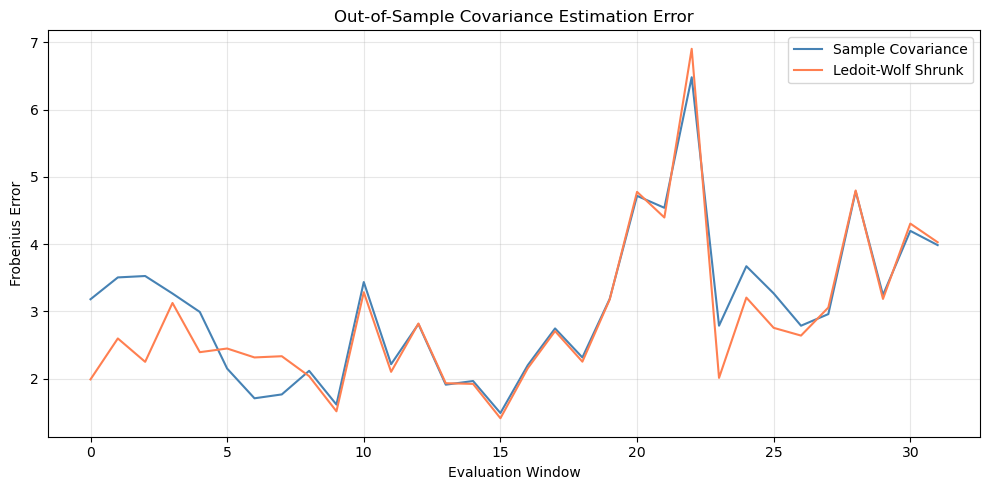

In [7]:
"""
==================================
Out-of-sample comparison: sample vs. shrunk covariance
==================================

We use a rolling window: estimate covariance on trailing 60 months,
compute portfolio variance forecast, compare to realized variance
over the next month. Lower Frobenius error = better estimator.
"""
window = 60
dates = df_returns.index
errors_sample = []
errors_shrunk = []

for i in range(window, len(dates) - 1, 6):  # Every 6 months for speed
    train = df_returns.iloc[i-window:i].dropna(axis=1, thresh=window//2).dropna()
    test = df_returns.iloc[i:i+1][train.columns]
    
    if test.shape[1] < 20:
        continue
    
    # Shrunk covariance (recompute on this window)
    lw = ledoit_wolf_shrinkage(df_returns.iloc[i-window:i])
    S_shrunk = lw['cov_shrunk']
    
    # Find common tickers between train and the shrunk estimator
    common = train.columns.intersection(lw['tickers'])
    if len(common) < 20:
        continue
    
    # Sample covariance on common tickers only
    train_common = train[common]
    S_sample = np.cov(train_common, rowvar=False, ddof=1)
    
    # Shrunk covariance aligned to common tickers
    S_shrunk_aligned = pd.DataFrame(
        S_shrunk, index=lw['tickers'], columns=lw['tickers']
    ).loc[common, common].values
    
    # Realized covariance (outer product of next month's returns) on common tickers
    test_common = test[common]
    realized = np.outer(test_common.values[0], test_common.values[0])
    
    err_sample = np.linalg.norm(S_sample - realized, 'fro')
    err_shrunk = np.linalg.norm(S_shrunk_aligned - realized, 'fro')
    
    errors_sample.append(err_sample)
    errors_shrunk.append(err_shrunk)

print(f"Number of evaluation windows: {len(errors_sample)}")
print(f"Mean Frobenius error (sample): {np.mean(errors_sample):.4f}")
print(f"Mean Frobenius error (shrunk): {np.mean(errors_shrunk):.4f}")
print(f"Improvement: {(1 - np.mean(errors_shrunk)/np.mean(errors_sample))*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(errors_sample, label='Sample Covariance', color='steelblue')
ax.plot(errors_shrunk, label='Ledoit-Wolf Shrunk', color='coral')
ax.set_xlabel('Evaluation Window')
ax.set_ylabel('Frobenius Error')
ax.set_title('Out-of-Sample Covariance Estimation Error')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/ledoit_wolf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Portfolio Variance Decomposition

Let $B\in\mathbb{R}^{N\times k}$ hold the top $k$ eigenvectors and let

$$\Sigma_f=\mathrm{diag}(\lambda_1,\ldots,\lambda_k).$$

The top-$k$ approximation to the covariance matrix is

$$\Sigma_{\text{factor}}=B\Sigma_fB^\top.$$

The residual covariance is

$$\Sigma_{\text{resid}}=\Sigma-B\Sigma_fB^\top.$$

For a portfolio $w$, variance splits exactly under this construction:

$$w^\top\Sigma w = w^\top\Sigma_{\text{factor}}w + w^\top\Sigma_{\text{resid}}w.$$

Geometrically, $B^\top w$ is the portfolio's exposure to the top PCA directions. The systematic term is the variance from those common directions. The residual term is everything left outside that retained subspace.

This is a PCA decomposition, not a full economic factor model. The first few PCs often resemble broad market or style factors, but the math itself only knows about covariance structure.

In [8]:
"""
==================================
Reconstruct the long portfolio weights at the last rebalance
==================================
"""
df_signal = pd.read_csv('../data/processed/momentum_signal.csv', index_col=0, parse_dates=True)

# Take the last rebalance date
last_date = df_signal.index[-2]  # -2 because we trade t+1
scores = df_signal.loc[last_date].dropna()

n_long = max(int(len(scores) * 0.1), 1)
long_tickers = scores.sort_values(ascending=False).head(n_long).index.tolist()

# Equal-weighted weights
w = pd.Series(1.0 / len(long_tickers), index=long_tickers)

print(f"Last rebalance: {last_date}")
print(f"Number of long holdings: {len(long_tickers)}")
print(f"Weight per stock: {w.iloc[0]:.4f}")

Last rebalance: 2025-11-30 00:00:00
Number of long holdings: 49
Weight per stock: 0.0204


Using top 9 PCs as statistical factors

### Portfolio Variance Decomposition

Total portfolio variance:      0.001336
Systematic (factor) variance:  0.001212  (90.7%)
Idiosyncratic variance:        0.000124  (9.3%)


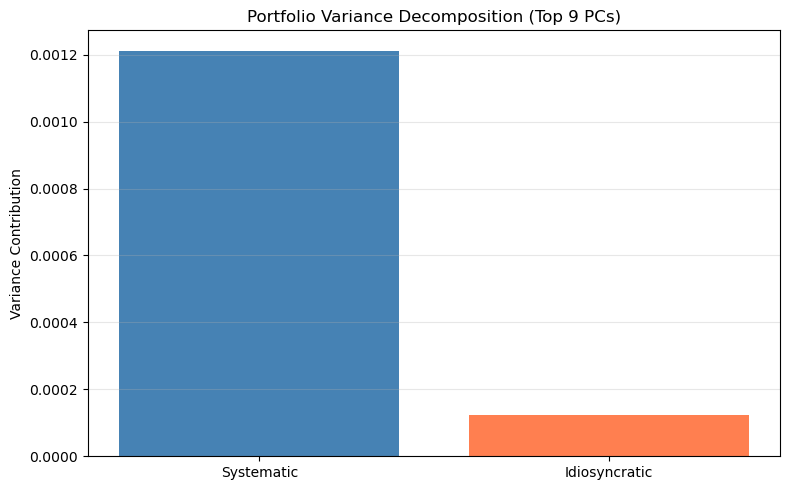

In [9]:
"""
==================================
Variance decomposition using top-k PCs as factors
==================================
"""
# Align weights to PCA tickers
pca_tickers = pca_result['tickers']
w_aligned = w.reindex(pca_tickers).fillna(0).values

cov = pca_result['cov']
eigenvalues = pca_result['eigenvalues']
eigenvectors = pca_result['eigenvectors']

k = n_signal  # Number of signal PCs
print(f"Using top {k} PCs as statistical factors")

# Factor loadings: B = eigenvectors (N x k)
B = eigenvectors[:, :k]

# Factor covariance: diagonal matrix of top-k eigenvalues
Sigma_f = np.diag(eigenvalues[:k])

# Idiosyncratic variance: residual variance per stock
# D = diag(Sigma - B Sigma_f B^T)
Sigma_factor = B @ Sigma_f @ B.T

# Portfolio variance
total_var = w_aligned @ cov @ w_aligned
systematic_var = w_aligned @ Sigma_factor @ w_aligned
# Idiosyncratic = variance in the orthogonal complement of the top-k factor
# subspace. Equals total - systematic by construction, so the split sums to 100%.
idiosyncratic_var = total_var - systematic_var

print(f"\n### Portfolio Variance Decomposition\n")
print(f"Total portfolio variance:      {total_var:.6f}")
print(f"Systematic (factor) variance:  {systematic_var:.6f}  ({systematic_var/total_var*100:.1f}%)")
print(f"Idiosyncratic variance:        {idiosyncratic_var:.6f}  ({idiosyncratic_var/total_var*100:.1f}%)")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(['Systematic', 'Idiosyncratic'], [systematic_var, idiosyncratic_var], 
       color=['steelblue', 'coral'])
ax.set_ylabel('Variance Contribution')
ax.set_title(f'Portfolio Variance Decomposition (Top {k} PCs)')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/variance_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

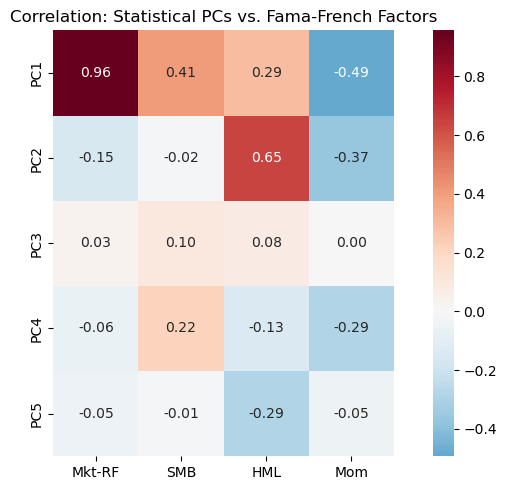

,Mkt-RF,SMB,HML,Mom
PC1,0.957,0.407,0.292,-0.493
PC2,-0.155,-0.022,0.646,-0.366
PC3,0.031,0.104,0.085,0.004
PC4,-0.059,0.221,-0.134,-0.288
PC5,-0.052,-0.012,-0.286,-0.048


In [10]:
"""
==================================
Compare statistical factors to known FF factors
==================================
"""
df_ff = pd.read_csv('../data/raw/ff_factors.csv', index_col=0, parse_dates=True)

# Project top PCs onto FF factor returns
# Align dates: df_returns has month-end, df_ff has month-start
# Convert to month-end timestamps, then normalize midnight for exact matching
common_dates = df_returns.index.to_period('M').intersection(
    df_ff.index.to_period('M')
).to_timestamp(how='end').normalize()
df_ret_aligned = df_returns.loc[common_dates, pca_tickers].dropna()
df_ff_aligned = df_ff.copy()
df_ff_aligned.index = df_ff_aligned.index.to_period('M').to_timestamp(how='end').normalize()
df_ff_aligned = df_ff_aligned.loc[df_ret_aligned.index]

# Compute PC returns: PC_i = eigenvector_i^T @ returns
pc_returns = pd.DataFrame(
    df_ret_aligned.values @ eigenvectors[:, :5],
    index=df_ret_aligned.index,
    columns=[f'PC{i+1}' for i in range(5)]
)

# Correlate PCs with FF factors
factor_cols = ['Mkt-RF', 'SMB', 'HML', 'Mom']
df_corr = pd.DataFrame(index=[f'PC{i+1}' for i in range(5)], columns=factor_cols)

for pc in pc_returns.columns:
    for ff in factor_cols:
        mask = pc_returns[pc].notna() & df_ff_aligned[ff].notna()
        df_corr.loc[pc, ff] = pc_returns.loc[mask, pc].corr(df_ff_aligned.loc[mask, ff])

df_corr = df_corr.astype(float)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Correlation: Statistical PCs vs. Fama-French Factors')

plt.tight_layout()
plt.savefig('../images/05_risk_decomposition/pc_vs_ff_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

display(df_corr.round(3))

In [11]:
"""
==================================
Save risk decomposition results
==================================
"""
decomp_results = pd.DataFrame({
    'component': ['total', 'systematic', 'idiosyncratic'],
    'variance': [total_var, systematic_var, idiosyncratic_var],
    'pct': [100, systematic_var/total_var*100, idiosyncratic_var/total_var*100]
})
decomp_results.to_csv('../data/processed/variance_decomposition.csv', index=False)

pd.DataFrame({
    'eigenvalue': eigenvalues[:50],
    'explained_pct': pca_result['explained_ratio'][:50] * 100
}).to_csv('../data/processed/pca_spectrum.csv', index=False)

print("Saved:")
print("  - variance_decomposition.csv")
print("  - pca_spectrum.csv")

Saved:
  - variance_decomposition.csv
  - pca_spectrum.csv


## Conclusion

This notebook decomposes the risk of the long-only momentum portfolio.

- The Marchenko-Pastur cutoff gives an objective estimate of how many covariance eigenvalues are too large to dismiss as random-matrix noise.
- Ledoit-Wolf shrinkage shows why the raw sample covariance should be treated cautiously when $N$ is large relative to $T$.
- The portfolio variance decomposition shows that most of the long-only portfolio's risk lives in common PCA directions rather than purely stock-specific residual risk.

One wording caveat: the Fama-French alpha from notebook 04 is orthogonal to the Fama-French benchmark factors, not literally to these PCA directions. The two ideas are related because both are factor decompositions, but they are not the same basis.

Notebook 06 uses the PCA factor structure to generate alternate market histories and ask whether the observed alpha looks unusually lucky.